# Quantum Circuit Simulation for Quantum State Discrimination

UQSD for now

In [1]:
from utils import *

## Load the target circuit

In [ ]:
# nq = 2
nq = 6
ns = 3
# seed = 1
# case_id = f"q{nq}_n{ns}_s{seed}"
case_id = f"q{nq}_n{ns}"
qasm_name = f"circuits/coherent/coh_{case_id}_no_backend_resynth.qasm"
# TODO add resynth back
qasm_name = f"circuits/coherent/symm/coh_symm_q3_n3_optuqsd_reducedpovm_csd_no_backend.qasm"

In [3]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit.from_qasm_file(qasm_name)
print(qc.num_qubits)
print(qc.count_ops())
print(qc.depth())

4
OrderedDict({'u': 122, 'cx': 73})
145


In [4]:
import logging

logging.basicConfig(
    filename=f"sim_{case_id}.log",
    filemode="a",
    format="{asctime} {levelname} {filename}:{lineno}: {message}",
    datefmt="%Y-%m-%d %H:%M:%S",
    style="{",
    level=logging.INFO,
    encoding="utf-8",
)
logger = logging.getLogger(__name__)

## Warm up: some quick checks

In [5]:
"""# Debug POVM and Phi_tilde
import numpy as np

np.set_printoptions(precision=4)
# Phi = np.load(f"Phi_{case_id}.npy")
# Phi_tilde = np.load(f"Phi_tilde_{case_id}.npy")
Phi = np.load(f"Phi_{case_id}_symm.npy")
Phi_tilde = np.load(f"Phi_tilde_{case_id}_symm.npy")
# povm = np.load(f"povm_{case_id}.npy")

print(Phi)  # target states
print(Phi_tilde)
# print(povm)
np.matmul(Phi_tilde.conj(), Phi)  # Should be identity
"""

'# Debug POVM and Phi_tilde\nimport numpy as np\n\nnp.set_printoptions(precision=4)\n# Phi = np.load(f"Phi_{case_id}.npy")\n# Phi_tilde = np.load(f"Phi_tilde_{case_id}.npy")\nPhi = np.load(f"Phi_{case_id}_symm.npy")\nPhi_tilde = np.load(f"Phi_tilde_{case_id}_symm.npy")\n# povm = np.load(f"povm_{case_id}.npy")\n\nprint(Phi)  # target states\nprint(Phi_tilde)\n# print(povm)\nnp.matmul(Phi_tilde.conj(), Phi)  # Should be identity\n'

In [6]:
import sys
import time
import tracemalloc
import qiskit.transpiler
import qiskit.synthesis
import qiskit
from qiskit import transpile

qc = transpile(qc, basis_gates=["rx", "ry", "rz", "cx"])
print(int(qc.depth() * 0.05))
qc_approx = transpile(
    circuits=qc,
    unitary_synthesis_method="aqc",
    unitary_synthesis_plugin_config={
        "network_layout": "cart",
        "connectivity_type": "star",
        "depth": int(qc.depth() * 0.05),
    },
)
print("Approx")
print(qc_approx.count_ops())
print(qc_approx.depth())

10
Approx
OrderedDict({'cx': 73, 'u3': 70, 'rz': 28, 'ry': 24})
145


In [7]:
qc.num_qubits

4

In [8]:
## # [:-15] Remove "no_backend.qasm" and add "ibm_brisbane.qasm"
'''
# qc_full = QuantumCircuit.from_qasm_file(qasm_name[:-15] + "ibm_brisbane.qasm")
qc_full = QuantumCircuit.from_qasm_file(qasm_name[:-23] + "ibm_fez.qasm")
print(qc_full.count_ops())
print(qc_full.depth())
'''

'\n# qc_full = QuantumCircuit.from_qasm_file(qasm_name[:-15] + "ibm_brisbane.qasm")\nqc_full = QuantumCircuit.from_qasm_file(qasm_name[:-23] + "ibm_fez.qasm")\nprint(qc_full.count_ops())\nprint(qc_full.depth())\n'

## Define handy simulation backends

In [9]:
from qiskit_aer import AerSimulator

AerSimulator().available_methods()

('automatic',
 'statevector',
 'density_matrix',
 'stabilizer',
 'matrix_product_state',
 'extended_stabilizer',
 'unitary',
 'superop')

In [10]:
sv_backend = AerSimulator(method="statevector", seed_simulator=42)
dm_backend = AerSimulator(method="density_matrix", seed_simulator=42)
sv_gpu_backend = AerSimulator(method="statevector", device="GPU", seed_simulator=42)
dm_gpu_backend = AerSimulator(method="density_matrix", device="GPU", seed_simulator=42)

## Load states

In [11]:
from flow.problem_spec import *

In [12]:
# states = ProblemSpec.gen_states(
#     num_qubits=nq,
#     num_states=ns,
#     seeds=get_random_seeds(ns, seed=seed),
#     state_type="statevector",
# )

from utils.handy_states import *
state_vec = coh_symm_small(num_qubits=6)["state_vec"]
states = [Statevector(_) for _ in state_vec]

# Ideal sim verification

Our original circuit does not contain final measurements

It is copied because measure_active creates new ClassicalRegisters every time

https://docs.quantum.ibm.com/guides/measure-qubits

The state discrimination circuit without the initial state

In [13]:
qc_tmp = qc_approx.copy()
qc_tmp.save_statevector()
qc_tmp.measure_active()

# Assume the job always got done quickly
result = sv_backend.run(qc_tmp).result()

In [14]:
result.get_counts()

{'0101': 167, '0010': 115, '0000': 117, '0001': 139, '1000': 486}

In [15]:
result.get_statevector()

Statevector([ 2.70615784e-01-2.25769301e-01j,
              2.70615784e-01-2.25769301e-01j,
              2.70615784e-01-2.25769301e-01j,
              5.39845946e-15+6.26582120e-15j,
              1.07741721e-02-8.98867489e-03j,
             -2.90775220e-01+2.42587913e-01j,
              1.23422741e-02-1.02969108e-02j,
             -5.48172618e-15+2.69229083e-15j,
              5.33945061e-01-4.45459617e-01j,
              1.78662283e-15-3.96396262e-15j,
              1.49880108e-15+7.63278329e-16j,
              3.77941849e-15+1.51406158e-15j,
              2.28680441e-16-6.80521861e-16j,
              4.56997713e-16+6.75140177e-16j,
             -1.37902595e-15-6.42972110e-16j,
              1.99306153e-16+1.98539535e-15j],
            dims=(2, 2, 2, 2))


In [16]:
result.get_statevector().probabilities().round(15)

array([1.24204680e-01, 1.24204680e-01, 1.24204680e-01, 0.00000000e+00,
       1.96879060e-04, 1.43399124e-01, 2.58358103e-04, 0.00000000e+00,
       4.83531599e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

## Construct DUT
The circuit with one of the target initial states

In [17]:
from qiskit_aer.library import SetStatevector, set_statevector, SetDensityMatrix
from qiskit.quantum_info import Statevector

# dut = QuantumCircuit(qc.num_qubits)
dut = QuantumCircuit(nq)
inst = dut.set_statevector(states[2]).instructions
# inst = dut.set_statevector(states[2].expand(Statevector([1, 0]))).instructions
# inst = dut.set_statevector(states[2].expand(Statevector([1, 0])).expand(Statevector([1, 0]))).instructions
dut.append(inst[0], [_ for _ in range(nq)])
# dut.save_statevector()
dut.append(qc, [_ for _ in range(qc.num_qubits)])
# dut.id(0)
dut.save_statevector()
dut.measure_active()

In [18]:
dut.decompose(reps=1).draw(style="mpl")  # May be large
dut.draw(style="mpl")

░  ░ ┌──────────────┐ statevector  ░ ┌─┐               
   q_0: ─░──░─┤0             ├──────░───────░─┤M├───────────────
         ░  ░ │              │      ░       ░ └╥┘┌─┐            
   q_1: ─░──░─┤1             ├──────░───────░──╫─┤M├────────────
         ░  ░ │  circuit-157 │      ░       ░  ║ └╥┘┌─┐         
   q_2: ─░──░─┤2             ├──────░───────░──╫──╫─┤M├─────────
         ░  ░ │              │      ░       ░  ║  ║ └╥┘┌─┐      
   q_3: ─░──░─┤3             ├──────░───────░──╫──╫──╫─┤M├──────
         ░  ░ └──────────────┘      ░       ░  ║  ║  ║ └╥┘┌─┐   
   q_4: ─░──░───────────────────────░───────░──╫──╫──╫──╫─┤M├───
         ░  ░                       ░       ░  ║  ║  ║  ║ └╥┘┌─┐
   q_5: ─░──░───────────────────────░───────░──╫──╫──╫──╫──╫─┤M├
         ░  ░                       ░       ░  ║  ║  ║  ║  ║ └╥┘
meas: 6/═══════════════════════════════════════╩══╩══╩══╩══╩══╩═
                                               0  1  2  3  4  5

In [19]:
dut = dut.decompose(reps=3)

In [20]:
result = sv_backend.run(dut).result()

In [ ]:
result.get_counts()

{'000010': 591, '001001': 176, '001000': 257}

In [22]:
result.get_statevector()

Statevector([ 1.03970018e-03+3.07641805e-04j,
              6.31790394e-04+8.87869114e-04j,
             -6.64240185e-02+7.46889628e-01j,
             -1.72803979e-05-9.86570451e-04j,
              1.34920450e-05+3.83382381e-05j,
             -7.16169205e-07+2.87811842e-05j,
              1.48835176e-05+1.65369165e-04j,
              7.47679180e-05-1.18155016e-04j,
             -4.60944555e-02+4.89535953e-01j,
             -4.42530300e-01+1.16568938e-02j,
             -8.63835361e-04-6.09156447e-04j,
              3.06964208e-04+4.06532387e-05j,
              7.90909604e-05-1.68662597e-04j,
              6.97684464e-06-3.22514489e-06j,
              3.30903280e-05+7.47445652e-06j,
              6.22536200e-06-1.45605959e-05j,
              3.18433075e-08-2.27258341e-08j,
              3.79416287e-08-9.53376956e-09j,
              5.81535412e-08-2.68826504e-08j,
             -4.25209634e-10+3.56504287e-10j,
              6.66329825e-09+2.40866189e-09j,
             -4.39475123e-08+2.050

In [23]:
result.get_statevector().probabilities().round(5)

array([0.     , 0.     , 0.56226, 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.24177, 0.19597, 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     ])

In [24]:
"""
for i in range(3):
    # TODO Choose the larger one
    dut = QuantumCircuit(qc.num_qubits)
    inst = dut.set_statevector(states[i].expand(Statevector([1, 0]))).instructions
    # inst = dut.set_statevector(states[2].expand(Statevector([1, 0])).expand(Statevector([1, 0]))).instructions
    dut.append(inst[0], [_ for _ in range(qc.num_qubits)])
    # dut.save_statevector()
    dut.append(qc, [_ for _ in range(qc.num_qubits)])
    dut.save_statevector()
    dut.measure_active()
    dut = dut.decompose(reps=3)
    result = sv_backend.run(dut).result()
    # Show results
    print(result.get_counts())
    print(result.get_statevector().probabilities().round(15))
"""

'\nfor i in range(3):\n    # TODO Choose the larger one\n    dut = QuantumCircuit(qc.num_qubits)\n    inst = dut.set_statevector(states[i].expand(Statevector([1, 0]))).instructions\n    # inst = dut.set_statevector(states[2].expand(Statevector([1, 0])).expand(Statevector([1, 0]))).instructions\n    dut.append(inst[0], [_ for _ in range(qc.num_qubits)])\n    # dut.save_statevector()\n    dut.append(qc, [_ for _ in range(qc.num_qubits)])\n    dut.save_statevector()\n    dut.measure_active()\n    dut = dut.decompose(reps=3)\n    result = sv_backend.run(dut).result()\n    # Show results\n    print(result.get_counts())\n    print(result.get_statevector().probabilities().round(15))\n'

In [25]:
for i in range(3):
    # dut = QuantumCircuit(qc.num_qubits)
    dut = QuantumCircuit(nq)
    inst = dut.set_statevector(states[i]).instructions
    # inst = dut.set_statevector(states[i].expand(Statevector([1, 0]))).instructions
    # inst = dut.set_statevector(states[i].expand(Statevector([1, 0])).expand(Statevector([1, 0]))).instructions
    dut.append(inst[0], [_ for _ in range(nq)])
    # dut.save_statevector()
    dut.append(qc, [_ for _ in range(qc.num_qubits)])
    # dut.id(0)
    dut.save_statevector()
    dut.measure_active()
    dut = dut.decompose(reps=3)
    result = sv_backend.run(dut).result()
    # Show results
    print(result.get_counts())
    print(result.get_statevector().probabilities().round(5))
    # print(result.get_statevector().probabilities().round(10))

{'000000': 585, '001001': 178, '001000': 261}
[0.55857 0.      0.      0.      0.      0.      0.      0.      0.24453
 0.19689 0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.     ]
{'000001': 591, '001001': 176, '001000': 257}
[0.      0.56226 0.      0.      0.      0.      0.      0.      0.24177
 0.19597 0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0. 

In [26]:
# TODO
custom_backend = AerSimulator(
    configuration=None,
    properties=None,
    provider=None,
    method="density_matrix",
    noise_model="",
)

# Noisy sim extrapolation

In [27]:
from qiskit.providers import fake_provider

# fake_backend = qiskit.providers.fake_provider.Fake127QPulseV1()
fake_backend = qiskit.providers.fake_provider.GenericBackendV2(num_qubits=4)

In [28]:
# noise_model =  NoiseModel.from_backend()
# Define several noise models
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Kraus, SuperOp
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    pauli_error,
    depolarizing_error,
    thermal_relaxation_error,
)

In [29]:
# Construct a 1-qubit bit-flip and phase-flip errors
p_error = 0.05
bit_flip = pauli_error([("X", p_error), ("I", 1 - p_error)])
phase_flip = pauli_error([("Z", p_error), ("I", 1 - p_error)])
print(bit_flip)
print(phase_flip)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.05, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘
  P(1) = 0.95, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘
QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.05, Circuit = 
   ┌───┐
q: ┤ Z ├
   └───┘
  P(1) = 0.95, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘


In [30]:
# Compose two bit-flip and phase-flip errors
bitphase_flip = bit_flip.compose(phase_flip)
print(bitphase_flip)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.0025000000000000005, Circuit = 
   ┌───┐┌───┐
q: ┤ X ├┤ Z ├
   └───┘└───┘
  P(1) = 0.0475, Circuit = 
   ┌───┐┌───┐
q: ┤ X ├┤ I ├
   └───┘└───┘
  P(2) = 0.0475, Circuit = 
   ┌───┐┌───┐
q: ┤ I ├┤ Z ├
   └───┘└───┘
  P(3) = 0.9025, Circuit = 
   ┌───┐┌───┐
q: ┤ I ├┤ I ├
   └───┘└───┘


In [31]:
# Tensor product two bit-flip and phase-flip errors with
# bit-flip on qubit-0, phase-flip on qubit-1
error2 = phase_flip.tensor(bit_flip)
print(error2)

QuantumError on 2 qubits. Noise circuits:
  P(0) = 0.0025000000000000005, Circuit = 
     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ Z ├
     └───┘
  P(1) = 0.0475, Circuit = 
     ┌───┐
q_0: ┤ I ├
     ├───┤
q_1: ┤ Z ├
     └───┘
  P(2) = 0.0475, Circuit = 
     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ I ├
     └───┘
  P(3) = 0.9025, Circuit = 
     ┌───┐
q_0: ┤ I ├
     ├───┤
q_1: ┤ I ├
     └───┘


In [32]:
# Convert to Kraus operator
bit_flip_kraus = Kraus(bit_flip)
print(bit_flip_kraus)

Kraus([[[-9.74679434e-01+0.j,  0.00000000e+00+0.j],
        [ 0.00000000e+00+0.j, -9.74679434e-01+0.j]],

       [[ 0.00000000e+00+0.j,  2.23606798e-01+0.j],
        [ 2.23606798e-01+0.j, -4.96506831e-17+0.j]]],
      input_dims=(2,), output_dims=(2,))


In [33]:
# Convert to Superoperator
phase_flip_sop = SuperOp(phase_flip)
print(phase_flip_sop)

SuperOp([[1. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
         [0. +0.j, 0.9+0.j, 0. +0.j, 0. +0.j],
         [0. +0.j, 0. +0.j, 0.9+0.j, 0. +0.j],
         [0. +0.j, 0. +0.j, 0. +0.j, 1. +0.j]],
        input_dims=(2,), output_dims=(2,))


## Main dish

Even though in reality the noise should be complicated, we assume that if we target a certain type of error and optimize our circuits to perform well under this specific type of noise, it should perform better under general conditions. (Do we have something to support it? Not really. How does more noise increase the cost of simulation?)

So we first consider only two-qubit gate errors and try to reduce two-qubit gate counts.

Then we add other gate-unrelated noise?

Then we add single-qubit gate errors

Let's see how bad the circuit performs with two-qubit gate error

### How small should the two-qubit depolarizing error be for the circuit to perform well?

If you follow the examples and give the param 0.05 or 0.01, the performance is terrible.
1e-4? 1e-8?

In [34]:
# TODO collect different initial states
# Brute force the plot, please

# Should we save the noise model to a list? Or just initialize it every time?
# I guess building DUTs is more expensive?


def test_dut(dut, param, target_states: list[str] | None = None, noise_model=None):
    """Test DUT under the two-qubit depolarizing error"""
    noise_model = _two_qubit_depolarizing_noise_model(param)

    noise_result = sv_backend.run(dut, noise_model=noise_model).result()
    try:
        print(param)
        print("'001' count =", noise_result.get_counts()['001'])
    except:
        pass
    if target_states is None:
        return noise_result.get_statevector().probabilities()
    else:
        return [noise_result.get_statevector().probabilities()[state].item() for state in target_states]


def _two_qubit_depolarizing_noise_model(param):
    noise_model = NoiseModel()
    two_qubit_error = depolarizing_error(param, 2)
    noise_model.add_all_qubit_quantum_error(two_qubit_error, ["cx"])
    return noise_model

In [35]:
# Check different params
# Add references for better parameters?
params = [
    1e-6,
    2e-6,
    5e-6,
    1e-5,
    2e-5,
    5e-5,
    1e-4,
    2e-4,
    5e-4,
    1e-3,
    2e-3,
    5e-3,
    1e-2,
    2e-2,
    5e-2,
    1e-1,
]

In [36]:
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS

colors = list(TABLEAU_COLORS)

# Theoretical lines: Do we have one here?
## theo_points = 160
## theo_x_axis = np.linspace(0, 2, theo_points)
## theo_angles = np.linspace(0, 2 * np.pi, theo_points)
## for t in range(5):
##     theo = 0.5 * (1 + max(1 - (1 / 2**n) * t, 0) * cos(theo_angles))
##     plt.plot(theo_x_axis, theo, "-", color=colors[t], alpha=0.5)


result_0 = []
result_1 = []
result_2 = []
for p in params:
    # two_qubit_error = depolarizing_error(0.05, 2)  # Terrible
    # two_qubit_error = depolarizing_error(0.01, 2)  # Terrible
    # two_qubit_error = depolarizing_error(0.005, 2)  # Kind of bad
    # two_qubit_error = depolarizing_error(0.001, 2)  # Acceptable
    # two_qubit_error = depolarizing_error(0.0001, 2)  # Good
    # two_qubit_error = depolarizing_error(0.00001, 2)  # Good
    # a, b = test_dut(dut, p, ['000', '001'])
    a, b, c = test_dut(dut, p, [0, 1, 2])
    # print(a, b)
    print(a)
    print(b)
    print(c)
    result_0.append(a)
    result_1.append(b)
    result_2.append(c)


1e-06
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
2e-06
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
5e-06
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
1e-05
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
2e-05
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
5e-05
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.0001
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.0002
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.0005
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.001
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.002
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.005
1.1756199455742128e-06
1.1874706664280987e-06
0.5622562667051637
0.01
0.0018679302183139694
0.06626857690191472
0.02248923065998673
0.02
0.03808185809103796
0.10157757409651666
0.002689281028506713
0.05
0.05380

0


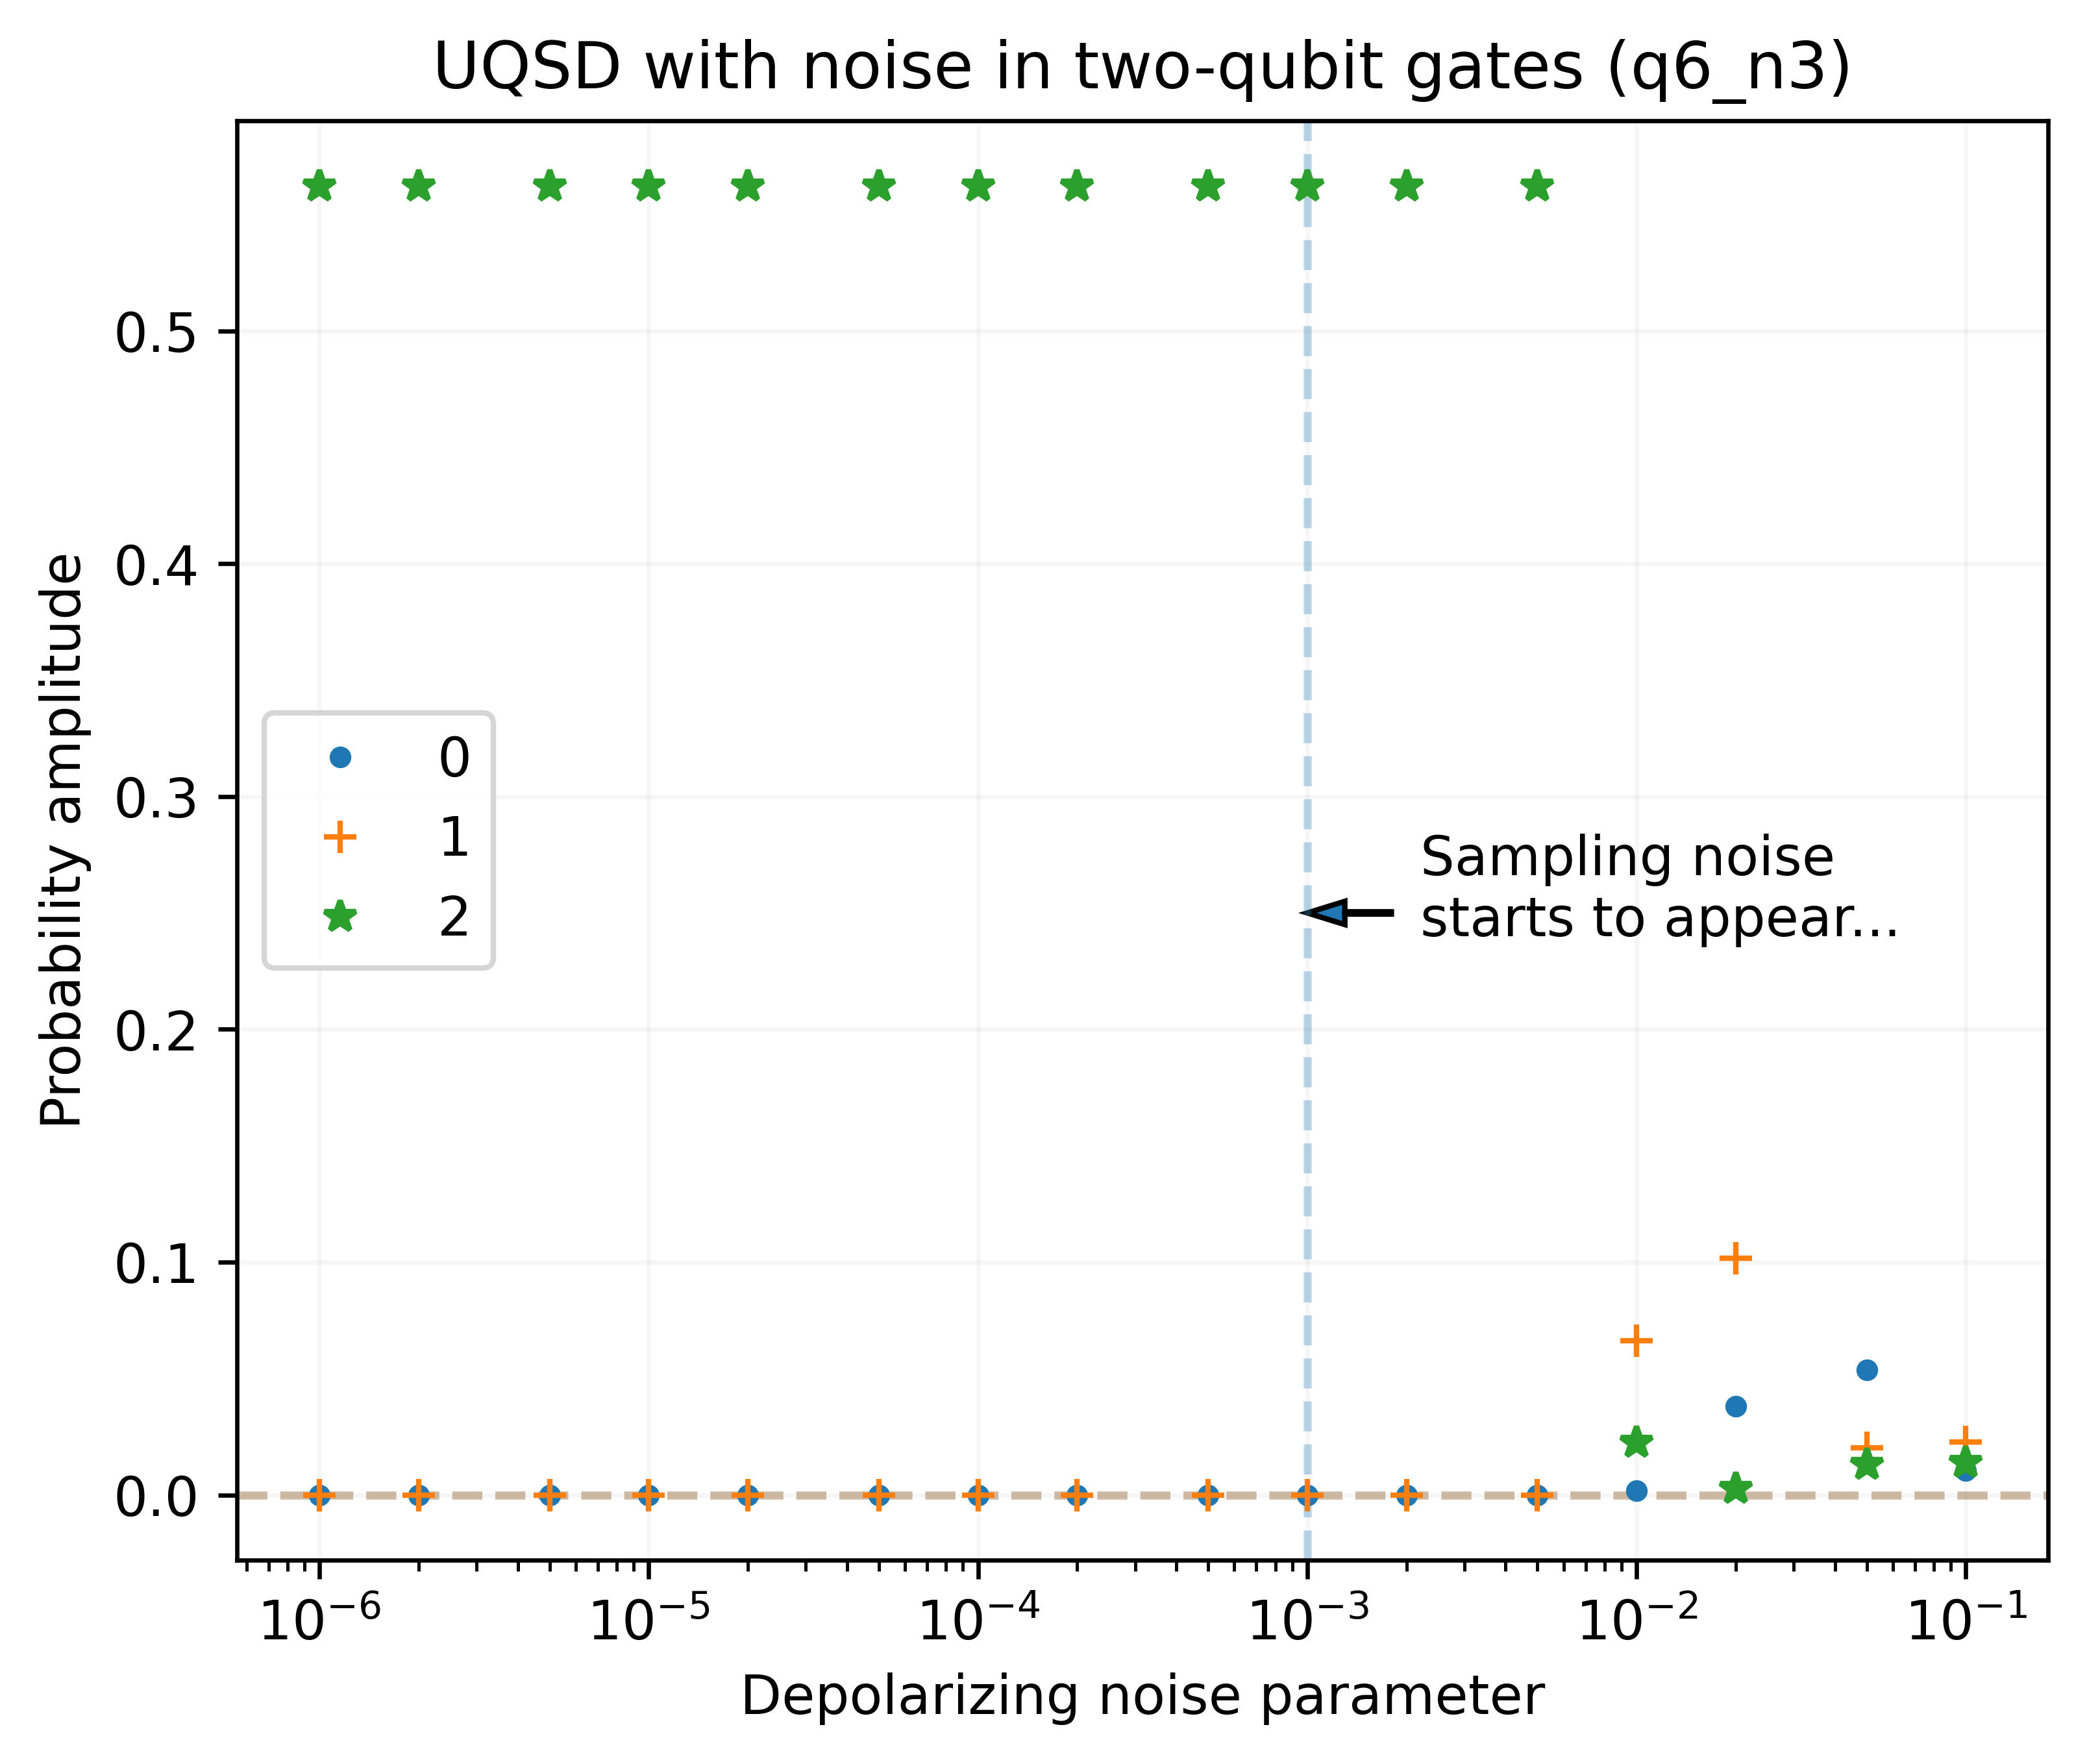

In [37]:
# TODO Save data to .npy or .npz

fig = plt.figure(dpi=600)
# fig = plt.figure(dpi=200)
fig.set_figwidth(6)
fig.set_figheight(4.8)
# fig.set_figwidth(3)
# fig.set_figheight(2.4)

plt.axvline(0.001, linestyle="--", alpha=0.3)
plt.arrow(0.0018, 0.25, -0.0005, 0, head_width=0.01, head_length=0.0003)
plt.text(0.0022, 0.24, "Sampling noise\n" + "starts to appear...")
plt.axhline(test_dut(dut, 0, [0]), linestyle="--", alpha=0.3, color=colors[0])
plt.axhline(0, linestyle="--", alpha=0.3, color=colors[1])

plt.xscale("log")
plt.plot(params, result_0, ".", label='0')# '"00" → "000"')
plt.plot(params, result_1, "+", label='1')# '"01" → "001"')
plt.plot(params, result_2, "*", label='2')# '"11" → "002"')

# plt.xlabel(r"$\theta / \pi$" + f" ({case_id})")
plt.xlabel("Depolarizing noise parameter")
plt.ylabel("Probability amplitude")
plt.legend(loc="center left")
plt.title(f"UQSD with noise in two-qubit gates ({case_id})")
plt.grid(True, alpha=0.1)

plt.savefig(
    fname=f"uqsd_optimal_csd_{case_id}.png",
    bbox_inches="tight",
)
plt.show()
plt.close()

In [38]:
# exp_x_axis = linspace(0, 2, num_points)
# plt.plot(exp_x_axis, prob, ".", label=f"t = {t}", color=colors[t])
# plt.xlabel(r"$\theta / \pi$" + f" ({num_points} points) (n = {n}, k = {k})")
# plt.title("First-order Interference (Aer Simulator)")

In [39]:
# Plot the probability amplitudes of different parameters
# Show the boundary of yes and no
# Instead of optimizing it, we obtain some intuition
# Check another file for this experiment

In [40]:
# Convert back to a quantum error
print(QuantumError(bit_flip_kraus))

# Check conversion is equivalent to original error
QuantumError(bit_flip_kraus) == bit_flip

QuantumError on 1 qubits. Noise circuits:
  P(0) = 1.0, Circuit = 
   ┌───────┐
q: ┤ kraus ├
   └───────┘


True